# Análisis exploratorio del dataset HAMLYN rectificado

**Proyecto integrador — Análisis de imágenes de endoscopia**  
**Equipo 52 — Maestría en Inteligencia Artificial Aplicada**

Este notebook continua la lógica metodológica aplicada previamente al dataset SCARED: primero se revisa la estructura física del dataset, después se realiza una ingesta de imágenes y mapas de profundidad, y finalmente se calculan métricas exploratorias para valorar la calidad, completitud y utilidad de los datos para tareas de visión computacional, estimación de profundidad y reconstrucción tridimensional.

## Objetivos

1. Verificar que HAMLYN rectificado fue descargado y descomprimido correctamente.
2. Construir un inventario de carpetas, archivos, formatos y tamaños.
3. Identificar imágenes RGB, pares estéreo y mapas de profundidad.
4. Leer archivos de calibración intrínseca.
5. Calcular estadísticas descriptivas de imágenes y profundidad.
6. Evaluar proporción de píxeles válidos e inválidos en mapas de profundidad.
7. Generar visualizaciones de control.
8. Exportar tablas y figuras para el reporte y GitHub.

> **Nota:** Los datos completos no deben subirse directamente a GitHub. Al repositorio se suben notebooks, scripts, README y resultados ligeros.

## 1. Configuración inicial

Estructura esperada:

```text
proyecto_integrador_52/
├── data/
│   └── hamlyn/
│       ├── raw_zip/
│       ├── intrinsics/
│       └── extracted/
│           ├── rectified01/
│           ├── rectified04/
│           ├── rectified05/
│           ├── rectified06/
│           └── rectified08/
├── notebooks/
└── outputs/
    └── hamlyn/
```

In [1]:
# Si falta alguna librería, ejecutar una sola vez:
# !pip install pandas numpy matplotlib pillow imageio tqdm

from pathlib import Path
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v3 as iio
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / "data" / "hamlyn").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
HAMLYN_DIR = PROJECT_ROOT / "data" / "hamlyn"
RAW_ZIP_DIR = HAMLYN_DIR / "raw_zip"
INTRINSICS_DIR = HAMLYN_DIR / "intrinsics"
EXTRACTED_DIR = HAMLYN_DIR / "extracted"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "hamlyn"

(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("HAMLYN_DIR:", HAMLYN_DIR)
print("EXTRACTED_DIR:", EXTRACTED_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52
HAMLYN_DIR: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn
EXTRACTED_DIR: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted
OUTPUT_DIR: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn


## 2. Verificación de descarga y descompresión

Se validan los ZIP, las carpetas extraídas y los archivos de calibración.

In [5]:
expected_sequences = ["rectified01", "rectified04", "rectified05", "rectified06", "rectified08"]

zip_inventory = []
for seq in expected_sequences:
    zip_path = RAW_ZIP_DIR / f"{seq}.zip"
    extracted_path = EXTRACTED_DIR / seq
    intrinsics_path = INTRINSICS_DIR / f"intrinsics_{seq}.txt"
    zip_inventory.append({
        "sequence": seq,
        "zip_exists": zip_path.exists(),
        "zip_size_mb": round(zip_path.stat().st_size / (1024**2), 2) if zip_path.exists() else np.nan,
        "extracted_exists": extracted_path.exists(),
        "intrinsics_exists": intrinsics_path.exists(),
        "intrinsics_size_kb": round(intrinsics_path.stat().st_size / 1024, 2) if intrinsics_path.exists() else np.nan
    })

zip_df = pd.DataFrame(zip_inventory)
display(zip_df)

zip_df.to_csv(OUTPUT_DIR / "tables" / "hamlyn_download_inventory.csv", index=False)

,sequence,zip_exists,zip_size_mb,extracted_exists,intrinsics_exists,intrinsics_size_kb
0,rectified01,True,188.48,True,True,0.07
1,rectified04,True,125.34,True,True,0.07
2,rectified05,True,80.86,True,True,0.07
3,rectified06,True,245.20,True,True,0.07
4,rectified08,True,2269.24,True,True,0.07


## 3. Inventario general de archivos

Esta sección cuantifica la volumetría del dataset: número de archivos por secuencia, extensión, tamaño total y organización general.

In [7]:
def list_files(base_dir):
    records = []
    base_dir = Path(base_dir)
    if not base_dir.exists():
        print(f"No existe la carpeta: {base_dir}")
        return pd.DataFrame()

    for path in base_dir.rglob("*"):
        if path.is_file():
            rel = path.relative_to(base_dir)
            parts = rel.parts
            seq = next((p for p in parts if p.startswith("rectified")), "unknown")
            records.append({
                "sequence": seq,
                "relative_path": str(rel),
                "filename": path.name,
                "extension": path.suffix.lower(),
                "size_mb": path.stat().st_size / (1024**2),
                "absolute_path": str(path)
            })
    return pd.DataFrame(records)

files_df = list_files(EXTRACTED_DIR)
print("Total de archivos descomprimidos:", len(files_df))
display(files_df.head())

if not files_df.empty:
    summary_ext = (
        files_df.groupby(["sequence", "extension"])
        .agg(n_files=("filename", "count"), total_size_mb=("size_mb", "sum"))
        .reset_index()
        .sort_values(["sequence", "extension"])
    )
    summary_ext["total_size_mb"] = summary_ext["total_size_mb"].round(2)
else:
    summary_ext = pd.DataFrame()

display(summary_ext)

files_df.to_csv(OUTPUT_DIR / "tables" / "hamlyn_all_files_inventory.csv", index=False)
summary_ext.to_csv(OUTPUT_DIR / "tables" / "hamlyn_filetype_summary.csv", index=False)

Total de archivos descomprimidos: 76640


,sequence,relative_path,filename,extension,size_mb,absolute_path
0,rectified04,rectified04/rectified04/image01/0000000544.jpg,0000000544.jpg,.jpg,0.027141,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...
1,rectified04,rectified04/rectified04/image01/0000000222.jpg,0000000222.jpg,.jpg,0.026549,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...
2,rectified04,rectified04/rectified04/image01/0000001128.jpg,0000001128.jpg,.jpg,0.030452,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...
3,rectified04,rectified04/rectified04/image01/0000000236.jpg,0000000236.jpg,.jpg,0.027350,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...
4,rectified04,rectified04/rectified04/image01/0000000550.jpg,0000000550.jpg,.jpg,0.026946,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...


,sequence,extension,n_files,total_size_mb
0,rectified01,.jpg,2116,71.60
1,rectified01,.png,2116,116.14
2,rectified04,.jpg,3146,84.76
3,rectified04,.png,3146,39.35
4,rectified05,.jpg,1798,53.63
5,rectified05,.png,1798,26.55
6,rectified06,.jpg,2474,103.34
7,rectified06,.png,2474,140.92
8,rectified08,.jpg,28786,1216.90
9,rectified08,.png,28786,1044.89


## 4. Muestra de estructura interna

Se imprime un árbol parcial por secuencia para documentar la organización física de carpetas.

In [9]:
def print_tree(path, max_depth=3, max_items_per_level=15):
    path = Path(path)
    if not path.exists():
        print(f"No existe: {path}")
        return

    def _print(current, prefix="", depth=0):
        if depth > max_depth:
            return
        items = sorted(list(current.iterdir()), key=lambda p: (p.is_file(), p.name.lower()))
        shown = items[:max_items_per_level]
        hidden = max(0, len(items) - max_items_per_level)
        for item in shown:
            marker = "📁" if item.is_dir() else "📄"
            print(f"{prefix}{marker} {item.name}")
            if item.is_dir():
                _print(item, prefix + "   ", depth + 1)
        if hidden:
            print(f"{prefix}... {hidden} elementos más")

    print(f"Árbol de: {path}")
    _print(path)

for seq in expected_sequences:
    print("\n" + "="*80)
    print_tree(EXTRACTED_DIR / seq)


Árbol de: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01
📁 rectified01
   📁 depth01
      📄 0000000000.png
      📄 0000000001.png
      📄 0000000002.png
      📄 0000000003.png
      📄 0000000004.png
      📄 0000000005.png
      📄 0000000006.png
      📄 0000000007.png
      📄 0000000008.png
      📄 0000000009.png
      📄 0000000010.png
      📄 0000000011.png
      📄 0000000012.png
      📄 0000000013.png
      📄 0000000014.png
      ... 1043 elementos más
   📁 depth02
      📄 0000000000.png
      📄 0000000001.png
      📄 0000000002.png
      📄 0000000003.png
      📄 0000000004.png
      📄 0000000005.png
      📄 0000000006.png
      📄 0000000007.png
      📄 0000000008.png
      📄 0000000009.png
      📄 0000000010.png
      📄 0000000011.png
      📄 0000000012.png
      📄 0000000013.png
      📄 0000000014.png
      ... 1043 elementos más
   📁 image01
      📄 0000000000.jpg
      📄 0000000001.jpg
      📄 0000000002.j

## 5. Clasificación heurística de archivos

Se clasifican los archivos por nombre, ruta y extensión. Como los datasets pueden tener estructuras heterogéneas, esta clasificación es inicial y se confirma leyendo metadatos.

In [11]:
def classify_file(row):
    path = str(row.get("relative_path", "")).lower()
    ext = row.get("extension", "").lower()

    if ext not in [".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"]:
        return "other"

    depth_terms = ["depth", "gt", "groundtruth", "ground_truth", "disp", "disparity"]
    if any(term in path for term in depth_terms):
        return "depth_map"

    left_terms = ["left", "/l/", "_l_", "image_02", "cam0", "left_image"]
    right_terms = ["right", "/r/", "_r_", "image_03", "cam1", "right_image"]

    if any(term in path for term in left_terms):
        return "left_image"
    if any(term in path for term in right_terms):
        return "right_image"

    return "other_image"

if not files_df.empty:
    files_df["file_role_heuristic"] = files_df.apply(classify_file, axis=1)
    role_summary = (
        files_df.groupby(["sequence", "file_role_heuristic"])
        .agg(n_files=("filename", "count"), total_size_mb=("size_mb", "sum"))
        .reset_index()
        .sort_values(["sequence", "file_role_heuristic"])
    )
    role_summary["total_size_mb"] = role_summary["total_size_mb"].round(2)
else:
    role_summary = pd.DataFrame()

display(role_summary)
role_summary.to_csv(OUTPUT_DIR / "tables" / "hamlyn_role_summary_heuristic.csv", index=False)

,sequence,file_role_heuristic,n_files,total_size_mb
0,rectified01,depth_map,2116,116.14
1,rectified01,other_image,2116,71.60
2,rectified04,depth_map,3146,39.35
3,rectified04,other_image,3146,84.76
4,rectified05,depth_map,1798,26.55
5,rectified05,other_image,1798,53.63
6,rectified06,depth_map,2474,140.92
7,rectified06,other_image,2474,103.34
8,rectified08,depth_map,28786,1044.89
9,rectified08,other_image,28786,1216.90


## 6. Lectura de metadatos de imágenes

Se inspecciona resolución, modo de color y formato sin cargar completamente todos los archivos a memoria.

In [13]:
image_exts = [".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"]
image_files_df = files_df[files_df["extension"].isin(image_exts)].copy() if not files_df.empty else pd.DataFrame()

def inspect_image_metadata(path):
    try:
        with Image.open(path) as img:
            return {"width": img.width, "height": img.height, "mode": img.mode, "format": img.format}
    except Exception:
        return {"width": np.nan, "height": np.nan, "mode": "ERROR", "format": "ERROR"}

metadata_records = []
for _, row in tqdm(image_files_df.iterrows(), total=len(image_files_df), desc="Inspeccionando metadatos"):
    meta = inspect_image_metadata(row["absolute_path"])
    metadata_records.append({**row.to_dict(), **meta})

image_meta_df = pd.DataFrame(metadata_records)
print("Total de imágenes inspeccionadas:", len(image_meta_df))
display(image_meta_df.head())

if not image_meta_df.empty:
    resolution_summary = (
        image_meta_df.groupby(["sequence", "width", "height", "mode", "format", "file_role_heuristic"])
        .agg(n_files=("filename", "count"))
        .reset_index()
        .sort_values(["sequence", "n_files"], ascending=[True, False])
    )
else:
    resolution_summary = pd.DataFrame()

display(resolution_summary)

image_meta_df.to_csv(OUTPUT_DIR / "tables" / "hamlyn_image_metadata.csv", index=False)
resolution_summary.to_csv(OUTPUT_DIR / "tables" / "hamlyn_resolution_summary.csv", index=False)

Inspeccionando metadatos:   0%|          | 0/76640 [00:00<?, ?it/s]

Total de imágenes inspeccionadas: 76640


,sequence,relative_path,filename,extension,size_mb,absolute_path,file_role_heuristic,width,height,mode,format
0,rectified04,rectified04/rectified04/image01/0000000544.jpg,0000000544.jpg,.jpg,0.027141,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,other_image,360,288,RGB,JPEG
1,rectified04,rectified04/rectified04/image01/0000000222.jpg,0000000222.jpg,.jpg,0.026549,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,other_image,360,288,RGB,JPEG
2,rectified04,rectified04/rectified04/image01/0000001128.jpg,0000001128.jpg,.jpg,0.030452,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,other_image,360,288,RGB,JPEG
3,rectified04,rectified04/rectified04/image01/0000000236.jpg,0000000236.jpg,.jpg,0.027350,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,other_image,360,288,RGB,JPEG
4,rectified04,rectified04/rectified04/image01/0000000550.jpg,0000000550.jpg,.jpg,0.026946,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,other_image,360,288,RGB,JPEG


,sequence,width,height,mode,format,file_role_heuristic,n_files
0,rectified01,640,480,I;16,PNG,depth_map,2116
1,rectified01,640,480,RGB,JPEG,other_image,2116
2,rectified04,360,288,I;16,PNG,depth_map,3146
3,rectified04,360,288,RGB,JPEG,other_image,3146
4,rectified05,360,288,I;16,PNG,depth_map,1798
5,rectified05,360,288,RGB,JPEG,other_image,1798
6,rectified06,640,480,I;16,PNG,depth_map,2474
7,rectified06,640,480,RGB,JPEG,other_image,2474
8,rectified08,640,480,I;16,PNG,depth_map,28786
9,rectified08,640,480,RGB,JPEG,other_image,28786


## 7. Identificación de mapas de profundidad

En HAMLYN rectificado, los mapas de profundidad suelen almacenarse como PNG de 16 bits con valores en milímetros. Esta sección identifica posibles mapas de profundidad por tipo de dato y rango de valores.

In [15]:
def read_image_array(path):
    try:
        return iio.imread(path)
    except Exception:
        try:
            return np.array(Image.open(path))
        except Exception:
            return None

def infer_array_type(arr):
    if arr is None:
        return "error"
    if arr.ndim == 3 and arr.shape[-1] in [3, 4]:
        return "rgb_or_rgba"
    if arr.ndim == 2 and arr.dtype in [np.uint16, np.int16, np.uint32, np.float32, np.float64]:
        return "possible_depth"
    if arr.ndim == 2 and arr.dtype == np.uint8:
        return "grayscale_uint8"
    return "other"

candidate_depth_df = image_meta_df[image_meta_df["extension"].isin([".png", ".tif", ".tiff"])].copy()

depth_probe_records = []
for _, row in tqdm(candidate_depth_df.iterrows(), total=len(candidate_depth_df), desc="Revisando profundidad"):
    arr = read_image_array(row["absolute_path"])
    if arr is None:
        stats = {"array_type": "error", "dtype": "error", "ndim": np.nan, "shape": None,
                 "min": np.nan, "max": np.nan, "mean": np.nan}
    else:
        stats = {
            "array_type": infer_array_type(arr),
            "dtype": str(arr.dtype),
            "ndim": arr.ndim,
            "shape": str(arr.shape),
            "min": float(np.nanmin(arr)),
            "max": float(np.nanmax(arr)),
            "mean": float(np.nanmean(arr))
        }
    depth_probe_records.append({**row.to_dict(), **stats})

depth_probe_df = pd.DataFrame(depth_probe_records)

if not depth_probe_df.empty:
    depth_probe_df["is_depth_candidate"] = (
        (depth_probe_df["array_type"] == "possible_depth") |
        (depth_probe_df["file_role_heuristic"] == "depth_map") |
        ((depth_probe_df["extension"] == ".png") & (depth_probe_df["max"] > 255))
    )
    depth_candidates = depth_probe_df[depth_probe_df["is_depth_candidate"]].copy()
else:
    depth_candidates = pd.DataFrame()

print("Posibles mapas de profundidad detectados:", len(depth_candidates))
display(depth_candidates[["sequence", "relative_path", "dtype", "shape", "min", "max", "mean"]].head(20))

depth_probe_df.to_csv(OUTPUT_DIR / "tables" / "hamlyn_depth_probe.csv", index=False)
depth_candidates.to_csv(OUTPUT_DIR / "tables" / "hamlyn_depth_candidates.csv", index=False)

Revisando profundidad:   0%|          | 0/38320 [00:00<?, ?it/s]

Posibles mapas de profundidad detectados: 38320


,sequence,relative_path,dtype,shape,min,max,mean
0,rectified04,rectified04/rectified04/depth01/0000000949.png,uint16,"(288, 360)",0.0,64.0,29.248331
1,rectified04,rectified04/rectified04/depth01/0000000791.png,uint16,"(288, 360)",0.0,51.0,18.726379
2,rectified04,rectified04/rectified04/depth01/0000000785.png,uint16,"(288, 360)",0.0,54.0,24.464911
3,rectified04,rectified04/rectified04/depth01/0000000975.png,uint16,"(288, 360)",0.0,60.0,21.943403
4,rectified04,rectified04/rectified04/depth01/0000000961.png,uint16,"(288, 360)",0.0,60.0,24.267689
5,rectified04,rectified04/rectified04/depth01/0000000752.png,uint16,"(288, 360)",0.0,52.0,23.624267
6,rectified04,rectified04/rectified04/depth01/0000000034.png,uint16,"(288, 360)",0.0,53.0,23.564304
7,rectified04,rectified04/rectified04/depth01/0000000020.png,uint16,"(288, 360)",0.0,53.0,23.110523
8,rectified04,rectified04/rectified04/depth01/0000000746.png,uint16,"(288, 360)",0.0,52.0,21.770370
9,rectified04,rectified04/rectified04/depth01/0000001458.png,uint16,"(288, 360)",0.0,59.0,28.049035


## 8. Lectura de calibración intrínseca

Los archivos `intrinsics_rectifiedXX.txt` contienen parámetros de cámara necesarios para interpretar geométricamente las imágenes.

In [17]:
intrinsics_records = []

for seq in expected_sequences:
    intr_path = INTRINSICS_DIR / f"intrinsics_{seq}.txt"
    if intr_path.exists():
        text = intr_path.read_text(errors="ignore")
        numbers = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", text)
        numbers = [float(x) for x in numbers]
        intrinsics_records.append({
            "sequence": seq,
            "path": str(intr_path),
            "raw_text": text.strip(),
            "numbers_detected": numbers,
            "n_numbers": len(numbers)
        })
    else:
        intrinsics_records.append({
            "sequence": seq,
            "path": str(intr_path),
            "raw_text": None,
            "numbers_detected": [],
            "n_numbers": 0
        })

intrinsics_df = pd.DataFrame(intrinsics_records)
display(intrinsics_df[["sequence", "path", "n_numbers", "raw_text"]])

intrinsics_df[["sequence", "path", "n_numbers", "raw_text"]].to_csv(
    OUTPUT_DIR / "tables" / "hamlyn_intrinsics_summary.csv", index=False
)

,sequence,path,n_numbers,raw_text
0,rectified01,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/intrinsics/intrinsics_rectified01.txt,12,383.1901395 0 155.9659519195557 0\n0 383.1901395 124.3335933685303 0\n0 0 1 0
1,rectified04,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/intrinsics/intrinsics_rectified04.txt,12,579.05693 0 139.9316005706787 0\n0 579.05693 159.0189905166626 0\n0 0 1 0
2,rectified05,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/intrinsics/intrinsics_rectified05.txt,12,579.05693 0 139.9316005706787 0\n0 579.05693 159.0189905166626 0\n0 0 1 0
3,rectified06,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/intrinsics/intrinsics_rectified06.txt,12,765.8236885 0 276.4727783203125 0\n0 765.8236885 253.6752815246582 0\n0 0 1 0
4,rectified08,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/intrinsics/intrinsics_rectified08.txt,12,765.8236885 0 276.4727783203125 0\n0 765.8236885 253.6752815246582 0\n0 0 1 0


## 9. Estadísticas de profundidad

Criterio inicial de validez:

```text
1 mm <= profundidad <= 300 mm
```


In [19]:
MIN_VALID_DEPTH_MM = 1
MAX_VALID_DEPTH_MM = 300

# Para analizar toda la base: DEPTH_STRIDE = 1.
# Para pruebas rápidas: 10, 20, 50, etc.
DEPTH_STRIDE = 1

depth_files_to_process = depth_candidates.sort_values(["sequence", "relative_path"]).iloc[::DEPTH_STRIDE].copy()
print("Mapas de profundidad a procesar:", len(depth_files_to_process))

Mapas de profundidad a procesar: 38320


In [21]:
def compute_depth_stats(path, min_valid=1, max_valid=300):
    arr = read_image_array(path)
    if arr is None:
        return {"error": True}

    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = arr.astype(np.float32)

    total = arr.size
    valid_mask = np.isfinite(arr) & (arr >= min_valid) & (arr <= max_valid)
    valid = arr[valid_mask]

    result = {
        "error": False,
        "height": arr.shape[0],
        "width": arr.shape[1],
        "total_pixels": int(total),
        "valid_pixels": int(valid.size),
        "valid_pct": float(valid.size / total * 100),
        "invalid_pct": float((1 - valid.size / total) * 100)
    }

    if valid.size > 0:
        result.update({
            "depth_min_valid": float(np.min(valid)),
            "depth_max_valid": float(np.max(valid)),
            "depth_mean_valid": float(np.mean(valid)),
            "depth_median_valid": float(np.median(valid)),
            "depth_std_valid": float(np.std(valid))
        })
    else:
        result.update({
            "depth_min_valid": np.nan,
            "depth_max_valid": np.nan,
            "depth_mean_valid": np.nan,
            "depth_median_valid": np.nan,
            "depth_std_valid": np.nan
        })
    return result

depth_stats_records = []

for _, row in tqdm(depth_files_to_process.iterrows(), total=len(depth_files_to_process), desc="Profundidad"):
    stats = compute_depth_stats(row["absolute_path"], MIN_VALID_DEPTH_MM, MAX_VALID_DEPTH_MM)
    depth_stats_records.append({
        "sequence": row["sequence"],
        "relative_path": row["relative_path"],
        "filename": row["filename"],
        "absolute_path": row["absolute_path"],
        **stats
    })

depth_stats_df = pd.DataFrame(depth_stats_records)
display(depth_stats_df.head())

if not depth_stats_df.empty:
    depth_sequence_summary = (
        depth_stats_df.groupby("sequence")
        .agg(
            n_depth_maps=("filename", "count"),
            mean_valid_pct=("valid_pct", "mean"),
            median_valid_pct=("valid_pct", "median"),
            mean_invalid_pct=("invalid_pct", "mean"),
            mean_depth_mm=("depth_mean_valid", "mean"),
            median_depth_mm=("depth_median_valid", "median"),
            min_depth_mm=("depth_min_valid", "min"),
            max_depth_mm=("depth_max_valid", "max"),
            mean_std_depth_mm=("depth_std_valid", "mean")
        )
        .reset_index()
    )
    numeric_cols = depth_sequence_summary.select_dtypes(include=[np.number]).columns
    depth_sequence_summary[numeric_cols] = depth_sequence_summary[numeric_cols].round(3)
else:
    depth_sequence_summary = pd.DataFrame()

display(depth_sequence_summary)

depth_stats_df.to_csv(OUTPUT_DIR / "tables" / "hamlyn_depth_stats_by_file.csv", index=False)
depth_sequence_summary.to_csv(OUTPUT_DIR / "tables" / "hamlyn_depth_summary_by_sequence.csv", index=False)

Profundidad:   0%|          | 0/38320 [00:00<?, ?it/s]

,sequence,relative_path,filename,absolute_path,error,height,width,total_pixels,valid_pixels,valid_pct,invalid_pct,depth_min_valid,depth_max_valid,depth_mean_valid,depth_median_valid,depth_std_valid
0,rectified01,rectified01/rectified01/depth01/0000000000.png,0000000000.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,254308,82.782552,17.217448,55.0,110.0,81.343445,83.0,10.380792
1,rectified01,rectified01/rectified01/depth01/0000000001.png,0000000001.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,256241,83.411784,16.588216,55.0,113.0,81.384384,83.0,10.312531
2,rectified01,rectified01/rectified01/depth01/0000000002.png,0000000002.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,259449,84.456055,15.543945,55.0,113.0,81.081093,82.0,10.092916
3,rectified01,rectified01/rectified01/depth01/0000000003.png,0000000003.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,260880,84.921875,15.078125,55.0,109.0,81.013077,82.0,10.223222
4,rectified01,rectified01/rectified01/depth01/0000000004.png,0000000004.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,260924,84.936198,15.063802,55.0,113.0,81.159508,83.0,10.230902


,sequence,n_depth_maps,mean_valid_pct,median_valid_pct,mean_invalid_pct,mean_depth_mm,median_depth_mm,min_depth_mm,max_depth_mm,mean_std_depth_mm
0,rectified01,2116,72.830,75.860,27.170,79.483,83.0,9.0,300.0,11.479
1,rectified04,3146,53.055,53.807,46.945,43.589,42.0,26.0,300.0,3.393
2,rectified05,1798,46.261,46.468,53.739,46.176,47.0,35.0,300.0,3.987
3,rectified06,2474,79.267,81.983,20.733,115.676,125.0,21.0,300.0,20.337
4,rectified08,28786,35.400,35.206,64.600,70.640,63.0,16.0,300.0,14.356


## 10. Estadísticas de intensidad RGB

Se revisa el rango de intensidad, posible saturación y proporción de valores en cero para identificar problemas de iluminación o contraste.

In [23]:
depth_paths = set(depth_candidates["absolute_path"].tolist()) if not depth_candidates.empty else set()
rgb_candidates = image_meta_df[
    (~image_meta_df["absolute_path"].isin(depth_paths)) &
    (image_meta_df["extension"].isin([".jpg", ".jpeg", ".png"]))
].copy()

# Para analizar toda la base: RGB_STRIDE = 1.
RGB_STRIDE = 1
rgb_files_to_process = rgb_candidates.sort_values(["sequence", "relative_path"]).iloc[::RGB_STRIDE].copy()

print("Imágenes RGB a procesar:", len(rgb_files_to_process))

Imágenes RGB a procesar: 38320


In [25]:
def compute_rgb_stats(path):
    arr = read_image_array(path)
    if arr is None:
        return {"error": True}

    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]

    arr = arr.astype(np.float32)
    total_values = arr.size

    return {
        "error": False,
        "height": arr.shape[0],
        "width": arr.shape[1],
        "channels": arr.shape[2] if arr.ndim == 3 else 1,
        "min_intensity": float(np.min(arr)),
        "max_intensity": float(np.max(arr)),
        "mean_intensity": float(np.mean(arr)),
        "std_intensity": float(np.std(arr)),
        "zero_pct": float(np.sum(arr == 0) / total_values * 100),
        "saturated_255_pct": float(np.sum(arr >= 255) / total_values * 100),
        "mean_R": float(np.mean(arr[..., 0])) if arr.ndim == 3 else np.nan,
        "mean_G": float(np.mean(arr[..., 1])) if arr.ndim == 3 and arr.shape[-1] > 1 else np.nan,
        "mean_B": float(np.mean(arr[..., 2])) if arr.ndim == 3 and arr.shape[-1] > 2 else np.nan,
    }

rgb_stats_records = []

for _, row in tqdm(rgb_files_to_process.iterrows(), total=len(rgb_files_to_process), desc="RGB"):
    stats = compute_rgb_stats(row["absolute_path"])
    rgb_stats_records.append({
        "sequence": row["sequence"],
        "relative_path": row["relative_path"],
        "filename": row["filename"],
        "absolute_path": row["absolute_path"],
        **stats
    })

rgb_stats_df = pd.DataFrame(rgb_stats_records)
display(rgb_stats_df.head())

if not rgb_stats_df.empty:
    rgb_sequence_summary = (
        rgb_stats_df.groupby("sequence")
        .agg(
            n_rgb_images=("filename", "count"),
            mean_intensity=("mean_intensity", "mean"),
            std_intensity=("std_intensity", "mean"),
            min_intensity=("min_intensity", "min"),
            max_intensity=("max_intensity", "max"),
            mean_zero_pct=("zero_pct", "mean"),
            mean_saturated_255_pct=("saturated_255_pct", "mean"),
            mean_R=("mean_R", "mean"),
            mean_G=("mean_G", "mean"),
            mean_B=("mean_B", "mean")
        )
        .reset_index()
    )
    numeric_cols = rgb_sequence_summary.select_dtypes(include=[np.number]).columns
    rgb_sequence_summary[numeric_cols] = rgb_sequence_summary[numeric_cols].round(3)
else:
    rgb_sequence_summary = pd.DataFrame()

display(rgb_sequence_summary)

rgb_stats_df.to_csv(OUTPUT_DIR / "tables" / "hamlyn_rgb_stats_by_file.csv", index=False)
rgb_sequence_summary.to_csv(OUTPUT_DIR / "tables" / "hamlyn_rgb_summary_by_sequence.csv", index=False)

RGB:   0%|          | 0/38320 [00:00<?, ?it/s]

,sequence,relative_path,filename,absolute_path,error,height,width,channels,min_intensity,max_intensity,mean_intensity,std_intensity,zero_pct,saturated_255_pct,mean_R,mean_G,mean_B
0,rectified01,rectified01/rectified01/image01/0000000000.jpg,0000000000.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/im...,False,480,640,3,0.0,255.0,100.135750,47.241112,4.580946,0.003798,132.469864,85.786758,82.150627
1,rectified01,rectified01/rectified01/image01/0000000001.jpg,0000000001.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/im...,False,480,640,3,0.0,255.0,100.788177,47.441814,4.586480,0.003038,133.202957,86.386902,82.774673
2,rectified01,rectified01/rectified01/image01/0000000002.jpg,0000000002.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/im...,False,480,640,3,0.0,255.0,100.716316,47.348232,4.583442,0.003147,132.986404,86.357727,82.804688
3,rectified01,rectified01/rectified01/image01/0000000003.jpg,0000000003.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/im...,False,480,640,3,0.0,255.0,100.190529,47.235149,4.597656,0.002930,132.517365,85.848640,82.205612
4,rectified01,rectified01/rectified01/image01/0000000004.jpg,0000000004.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/im...,False,480,640,3,0.0,255.0,100.849876,47.453373,4.593207,0.004123,133.245682,86.536186,82.767761


,sequence,n_rgb_images,mean_intensity,std_intensity,min_intensity,max_intensity,mean_zero_pct,mean_saturated_255_pct,mean_R,mean_G,mean_B
0,rectified01,2116,95.099,46.361,0.0,255.0,4.500,0.001,125.145,81.567,78.584
1,rectified04,3146,74.209,60.409,0.0,255.0,5.163,0.471,122.091,51.134,49.402
2,rectified05,1798,82.562,65.525,0.0,255.0,4.751,0.851,114.752,68.531,64.403
3,rectified06,2474,106.653,45.431,0.0,255.0,4.298,0.012,138.626,91.897,89.437
4,rectified08,28786,81.598,50.614,0.0,255.0,4.552,0.010,111.999,67.029,65.766


## 11. Visualizaciones de control por secuencia

Se genera una figura por secuencia con:

1. imagen RGB;
2. mapa de profundidad normalizado;
3. máscara de profundidad válida;
4. histograma de profundidad válida.

In [27]:
def choose_sample_file(df, sequence):
    subset = df[df["sequence"] == sequence].copy()
    if subset.empty:
        return None
    subset = subset.sort_values("relative_path")
    return subset.iloc[len(subset)//2]["absolute_path"]

sample_pairs = []
for seq in expected_sequences:
    sample_pairs.append({
        "sequence": seq,
        "rgb_path": choose_sample_file(rgb_files_to_process, seq),
        "depth_path": choose_sample_file(depth_files_to_process, seq)
    })

sample_pairs_df = pd.DataFrame(sample_pairs)
display(sample_pairs_df)

,sequence,rgb_path,depth_path
0,rectified01,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/im...,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...
1,rectified04,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/de...
2,rectified05,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified05/rectified05/im...,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified05/rectified05/de...
3,rectified06,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified06/rectified06/im...,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified06/rectified06/de...
4,rectified08,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified08/rectified08/im...,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified08/rectified08/de...


Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/rectified01_control_visual.png


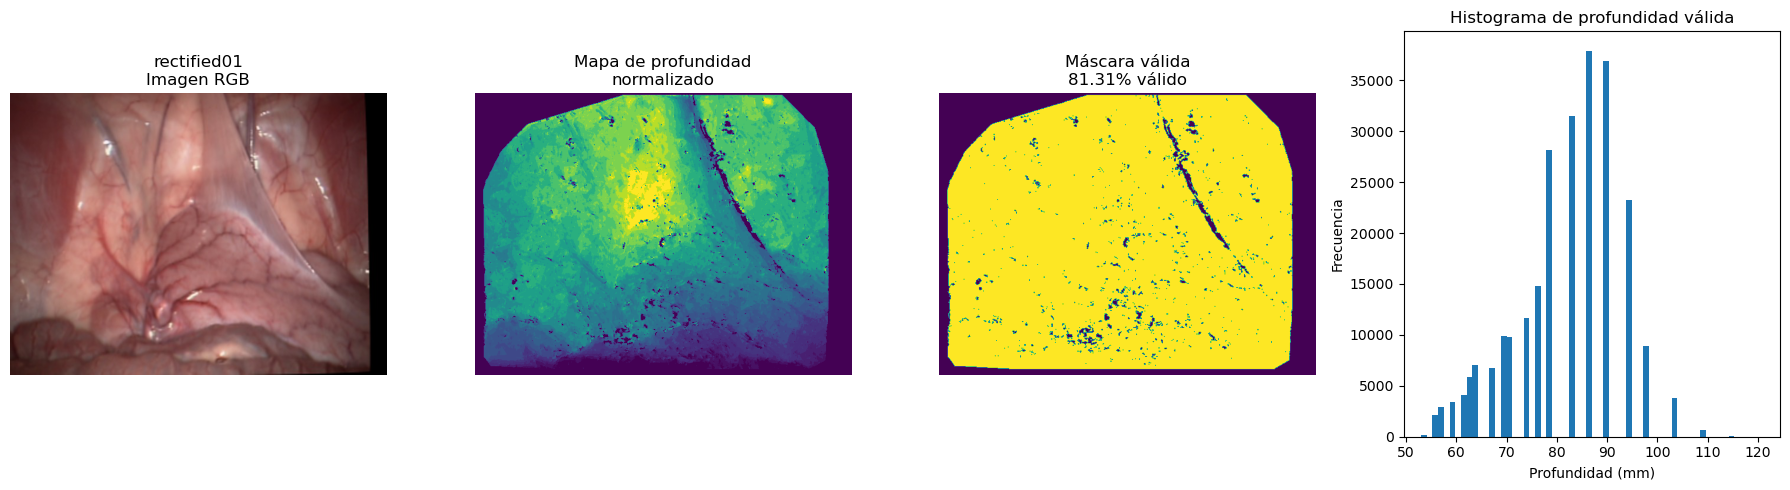

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/rectified04_control_visual.png


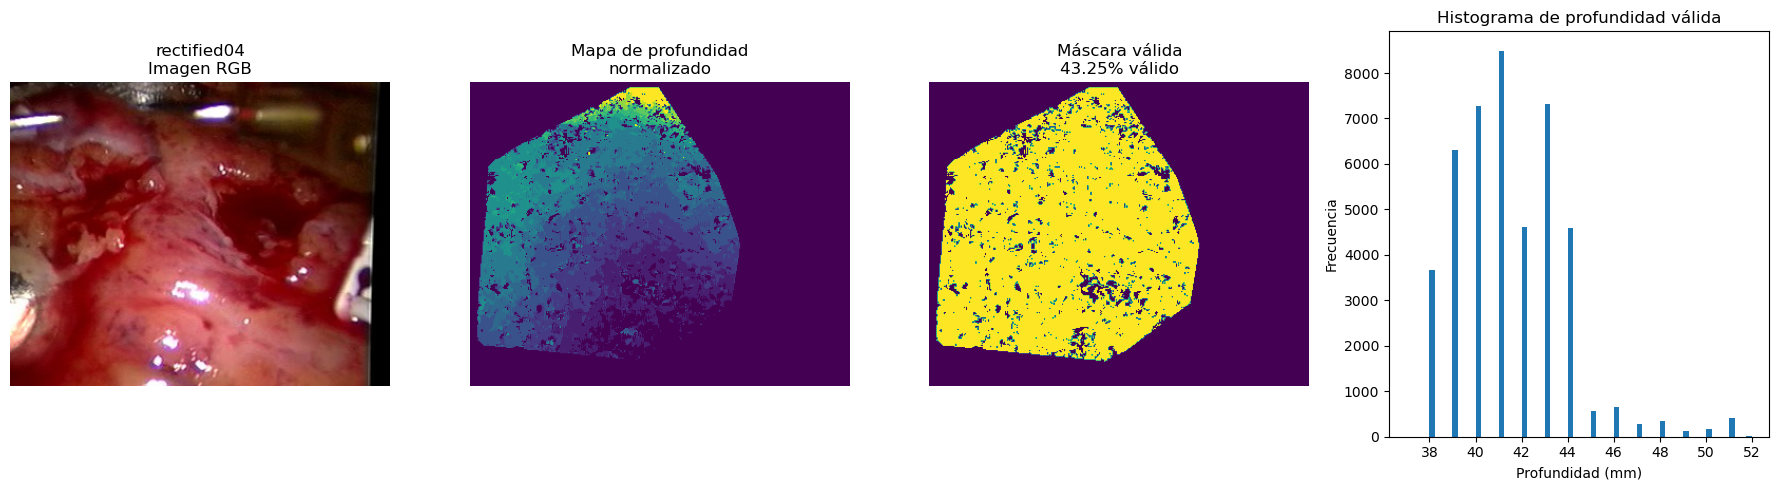

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/rectified05_control_visual.png


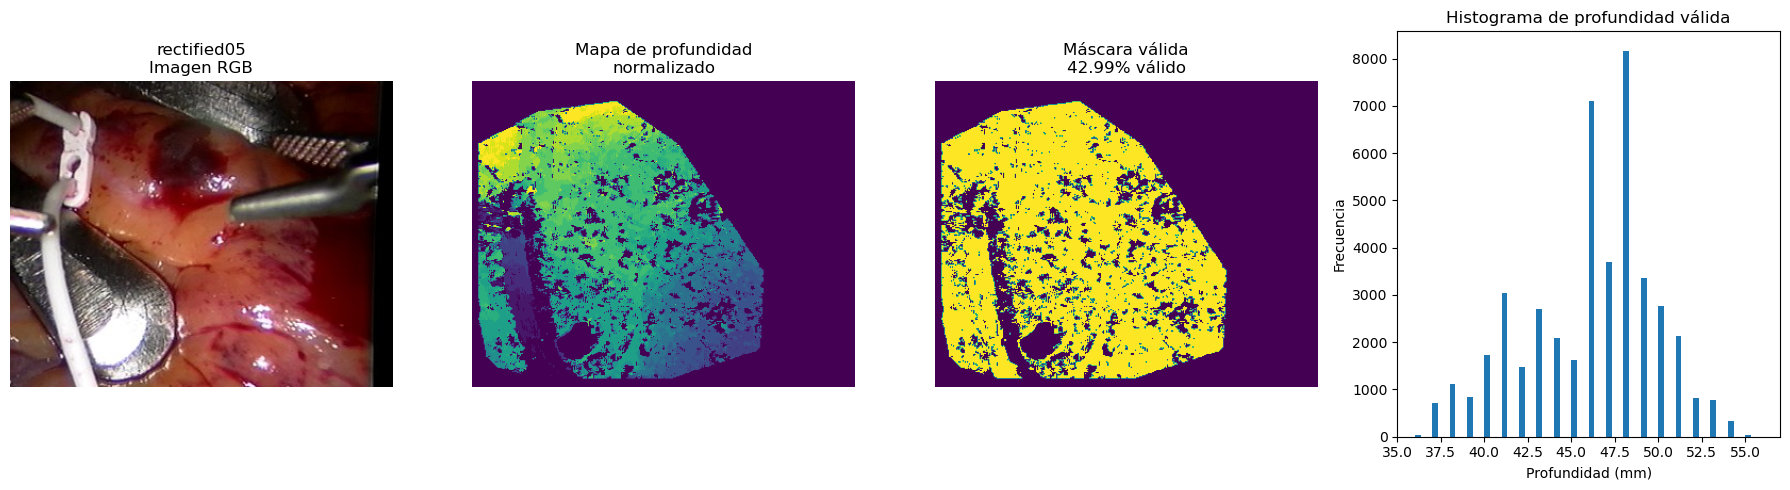

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/rectified06_control_visual.png


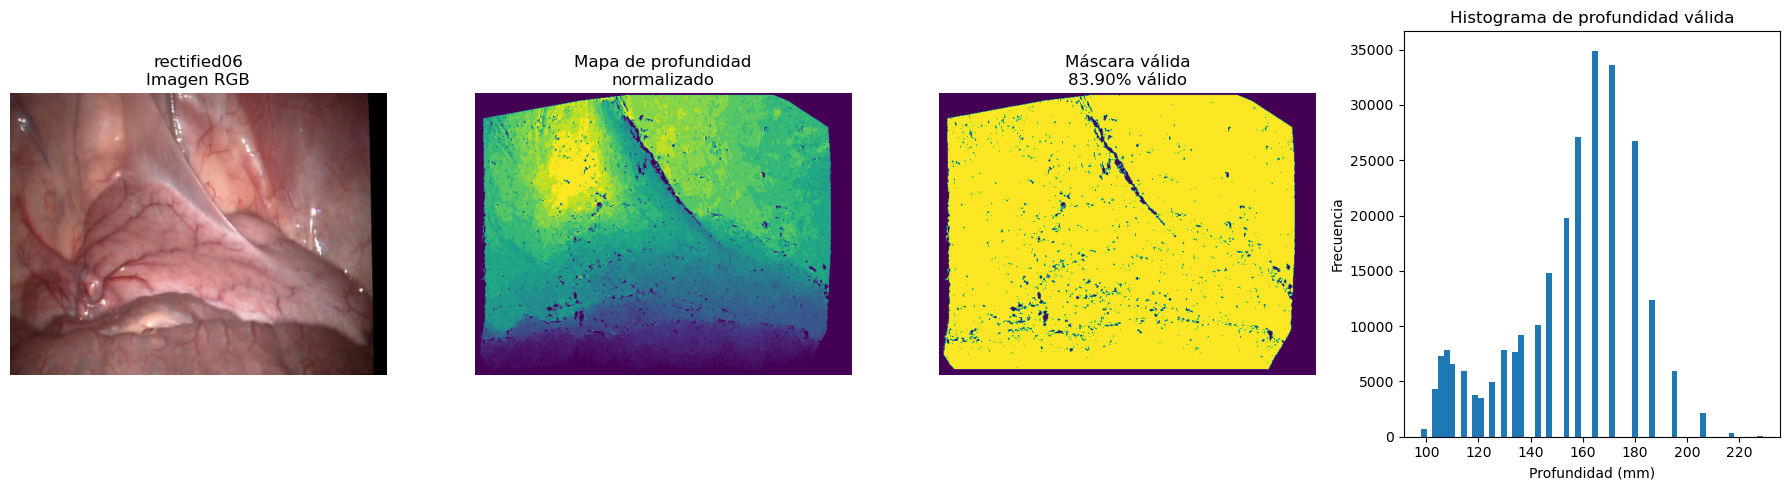

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/rectified08_control_visual.png


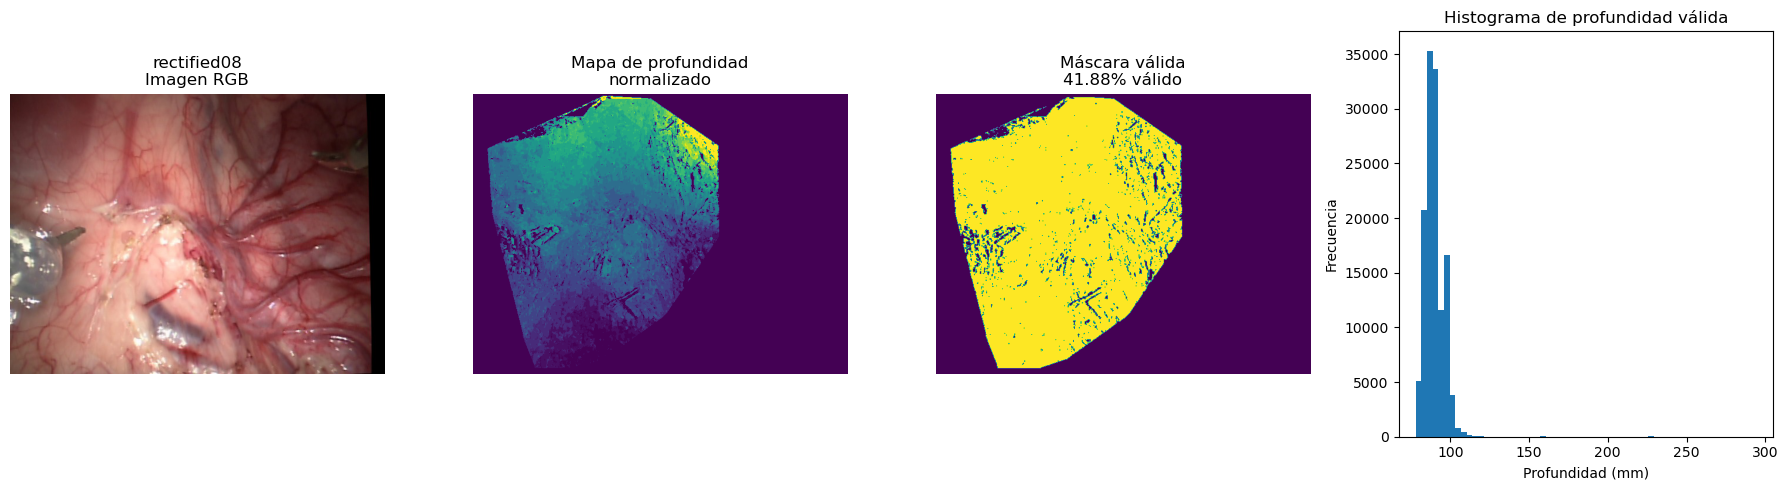

In [29]:
def normalize_for_display(arr, valid_mask=None):
    arr = arr.astype(np.float32)
    vals = arr[valid_mask] if valid_mask is not None and np.any(valid_mask) else arr[np.isfinite(arr)]
    if vals.size == 0:
        return np.zeros_like(arr, dtype=np.float32)
    p1, p99 = np.percentile(vals, [1, 99])
    if p99 <= p1:
        return np.zeros_like(arr, dtype=np.float32)
    return np.clip((arr - p1) / (p99 - p1), 0, 1)

def plot_sequence_control(sequence, rgb_path, depth_path, save=True):
    if rgb_path is None or depth_path is None:
        print(f"No hay suficientes archivos para {sequence}.")
        return

    rgb = read_image_array(rgb_path)
    depth = read_image_array(depth_path)
    if rgb is None or depth is None:
        print(f"Error leyendo archivos para {sequence}.")
        return

    rgb_disp = rgb if rgb.ndim == 2 else rgb[..., :3]
    if depth.ndim == 3:
        depth = depth[..., 0]
    depth = depth.astype(np.float32)

    valid_mask = np.isfinite(depth) & (depth >= MIN_VALID_DEPTH_MM) & (depth <= MAX_VALID_DEPTH_MM)
    depth_norm = normalize_for_display(depth, valid_mask)
    valid_depth = depth[valid_mask]

    fig = plt.figure(figsize=(18, 5))

    ax1 = plt.subplot(1, 4, 1)
    ax1.imshow(rgb_disp)
    ax1.set_title(f"{sequence}\nImagen RGB")
    ax1.axis("off")

    ax2 = plt.subplot(1, 4, 2)
    ax2.imshow(depth_norm)
    ax2.set_title("Mapa de profundidad\nnormalizado")
    ax2.axis("off")

    ax3 = plt.subplot(1, 4, 3)
    ax3.imshow(valid_mask)
    ax3.set_title(f"Máscara válida\n{valid_mask.mean()*100:.2f}% válido")
    ax3.axis("off")

    ax4 = plt.subplot(1, 4, 4)
    if valid_depth.size > 0:
        ax4.hist(valid_depth.flatten(), bins=60)
        ax4.set_title("Histograma de profundidad válida")
        ax4.set_xlabel("Profundidad (mm)")
        ax4.set_ylabel("Frecuencia")
    else:
        ax4.text(0.5, 0.5, "Sin profundidad válida", ha="center", va="center")
        ax4.set_axis_off()

    plt.tight_layout()

    if save:
        out_path = OUTPUT_DIR / "figures" / f"{sequence}_control_visual.png"
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
        print("Figura guardada:", out_path)

    plt.show()

for _, row in sample_pairs_df.iterrows():
    plot_sequence_control(row["sequence"], row["rgb_path"], row["depth_path"])

## 12. Gráficas agregadas entre secuencias

Estas gráficas resumen diferencias entre secuencias: proporción de profundidad válida, profundidad media e intensidad promedio.

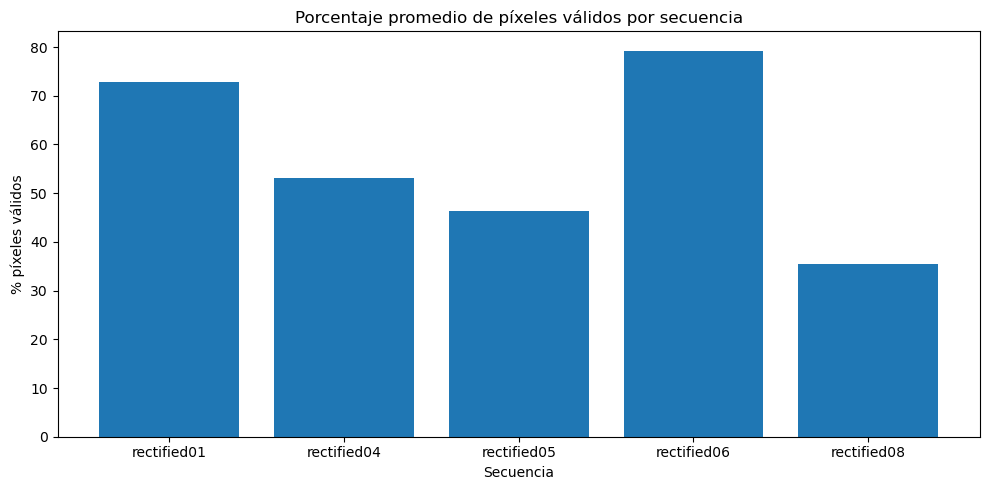

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/mean_valid_pct_by_sequence.png


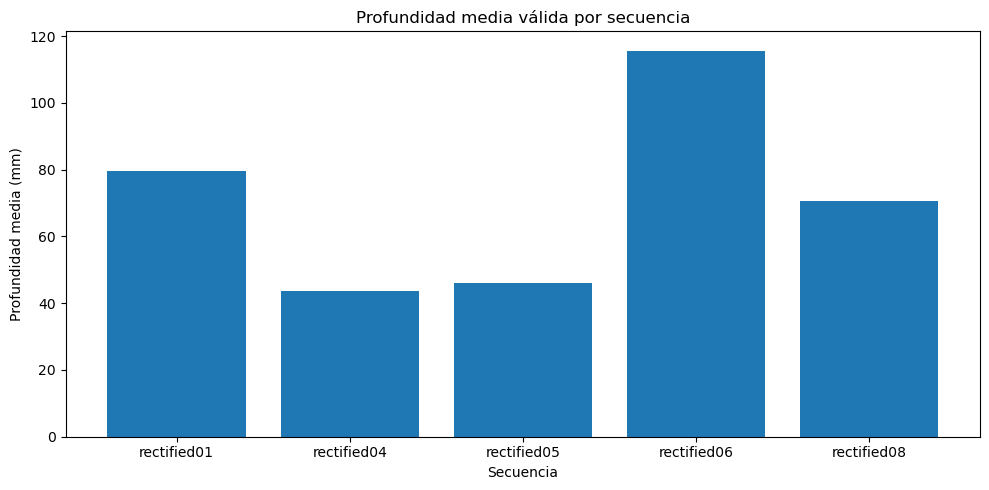

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/mean_depth_by_sequence.png


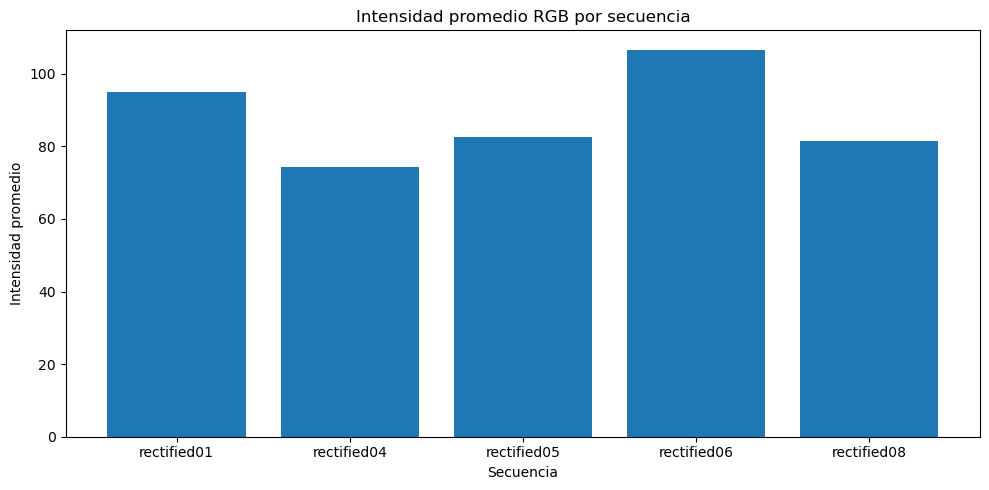

Figura guardada: /Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/outputs/hamlyn/figures/mean_rgb_intensity_by_sequence.png


In [31]:
def save_barplot(df, x, y, title, ylabel, filename):
    if df.empty or x not in df.columns or y not in df.columns:
        print(f"No hay datos para {title}")
        return

    plt.figure(figsize=(10, 5))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel("Secuencia")
    plt.ylabel(ylabel)
    plt.tight_layout()
    out_path = OUTPUT_DIR / "figures" / filename
    plt.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", out_path)

save_barplot(depth_sequence_summary, "sequence", "mean_valid_pct",
             "Porcentaje promedio de píxeles válidos por secuencia",
             "% píxeles válidos", "mean_valid_pct_by_sequence.png")

save_barplot(depth_sequence_summary, "sequence", "mean_depth_mm",
             "Profundidad media válida por secuencia",
             "Profundidad media (mm)", "mean_depth_by_sequence.png")

save_barplot(rgb_sequence_summary, "sequence", "mean_intensity",
             "Intensidad promedio RGB por secuencia",
             "Intensidad promedio", "mean_rgb_intensity_by_sequence.png")

## 13. Detección preliminar de valores atípicos

Se identifican archivos con bajo porcentaje de profundidad válida, saturación elevada o demasiados valores en cero.

In [33]:
LOW_VALID_THRESHOLD = 50
HIGH_SATURATION_THRESHOLD = 5
HIGH_ZERO_THRESHOLD = 5

depth_outliers = depth_stats_df[
    (depth_stats_df["valid_pct"] < LOW_VALID_THRESHOLD)
].copy() if not depth_stats_df.empty else pd.DataFrame()

rgb_outliers = rgb_stats_df[
    (rgb_stats_df["saturated_255_pct"] > HIGH_SATURATION_THRESHOLD) |
    (rgb_stats_df["zero_pct"] > HIGH_ZERO_THRESHOLD)
].copy() if not rgb_stats_df.empty else pd.DataFrame()

print("Posibles outliers en profundidad:", len(depth_outliers))
print("Posibles outliers RGB:", len(rgb_outliers))

display(depth_outliers.head(20))
display(rgb_outliers.head(20))

depth_outliers.to_csv(OUTPUT_DIR / "tables" / "hamlyn_depth_possible_outliers.csv", index=False)
rgb_outliers.to_csv(OUTPUT_DIR / "tables" / "hamlyn_rgb_possible_outliers.csv", index=False)

Posibles outliers en profundidad: 26740
Posibles outliers RGB: 18212


,sequence,relative_path,filename,absolute_path,error,height,width,total_pixels,valid_pixels,valid_pct,invalid_pct,depth_min_valid,depth_max_valid,depth_mean_valid,depth_median_valid,depth_std_valid
186,rectified01,rectified01/rectified01/depth01/0000000186.png,0000000186.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,148610,48.375651,51.624349,72.0,127.0,96.665344,98.0,8.544146
740,rectified01,rectified01/rectified01/depth01/0000000740.png,0000000740.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,146311,47.627279,52.372721,55.0,114.0,88.505447,90.0,11.336042
744,rectified01,rectified01/rectified01/depth01/0000000744.png,0000000744.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,147013,47.855794,52.144206,54.0,120.0,87.373924,88.0,12.634953
745,rectified01,rectified01/rectified01/depth01/0000000745.png,0000000745.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,142449,46.370117,53.629883,55.0,119.0,88.375854,88.0,12.142122
749,rectified01,rectified01/rectified01/depth01/0000000749.png,0000000749.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,123045,40.053711,59.946289,55.0,125.0,87.699944,88.0,12.727302
750,rectified01,rectified01/rectified01/depth01/0000000750.png,0000000750.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,146237,47.603190,52.396810,57.0,127.0,85.487091,87.0,12.277616
751,rectified01,rectified01/rectified01/depth01/0000000751.png,0000000751.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,129013,41.996419,58.003581,55.0,300.0,100.193581,93.0,30.846550
753,rectified01,rectified01/rectified01/depth01/0000000753.png,0000000753.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,106263,34.590820,65.409180,56.0,114.0,88.515915,90.0,10.759859
754,rectified01,rectified01/rectified01/depth01/0000000754.png,0000000754.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,117092,38.115885,61.884115,59.0,128.0,88.030602,90.0,10.965593
755,rectified01,rectified01/rectified01/depth01/0000000755.png,0000000755.png,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified01/rectified01/de...,False,480,640,307200,153269,49.892253,50.107747,57.0,300.0,85.727196,87.0,13.221585


,sequence,relative_path,filename,absolute_path,error,height,width,channels,min_intensity,max_intensity,mean_intensity,std_intensity,zero_pct,saturated_255_pct,mean_R,mean_G,mean_B
3689,rectified04,rectified04/rectified04/image02/0000000000.jpg,0000000000.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.705765,62.723499,8.226273,0.656507,123.406204,49.991531,47.719540
3690,rectified04,rectified04/rectified04/image02/0000000001.jpg,0000000001.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.812401,61.223854,7.686471,0.708591,122.723282,50.452930,48.260975
3691,rectified04,rectified04/rectified04/image02/0000000002.jpg,0000000002.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.505089,61.212997,7.591307,0.817258,122.413857,50.212086,47.889324
3692,rectified04,rectified04/rectified04/image02/0000000003.jpg,0000000003.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,74.038177,61.913712,7.338606,0.995049,121.859497,51.203693,49.051361
3693,rectified04,rectified04/rectified04/image02/0000000004.jpg,0000000004.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,72.790161,61.644127,7.248907,0.927533,119.765182,50.196999,48.408283
3694,rectified04,rectified04/rectified04/image02/0000000005.jpg,0000000005.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.892242,62.520798,7.262088,1.059671,119.927864,51.594395,50.154503
3695,rectified04,rectified04/rectified04/image02/0000000006.jpg,0000000006.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.456665,62.759727,7.258230,1.036201,118.985649,51.313251,50.071037
3696,rectified04,rectified04/rectified04/image02/0000000007.jpg,0000000007.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.011543,63.333549,7.233475,1.065458,117.929352,51.055199,50.050056
3697,rectified04,rectified04/rectified04/image02/0000000008.jpg,0000000008.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.520332,63.226871,7.312886,0.991834,118.714066,51.369156,50.477806
3698,rectified04,rectified04/rectified04/image02/0000000009.jpg,0000000009.jpg,/Users/eldamorales/Documents/Maestría en IA/Proyecto Integrador/proyecto_integrador_52/data/hamlyn/extracted/rectified04/rectified04/im...,False,288,360,3,0.0,255.0,73.031601,63.724224,7.479745,0.833655,119.048431,50.603973,49.442410


## 14. Resumen ejecutivo automático

Esta celda genera un texto base para redactar el apartado HAMLYN del reporte. 

In [35]:
def generate_summary_text():
    lines = []
    lines.append("Resumen exploratorio del dataset HAMLYN rectificado")
    lines.append("="*60)
    lines.append("")

    if not files_df.empty:
        lines.append(f"Se identificaron {len(files_df):,} archivos descomprimidos dentro de data/hamlyn/extracted.")
        lines.append(f"El tamaño total aproximado de archivos analizados es de {files_df['size_mb'].sum():,.2f} MB.")

    if not image_meta_df.empty:
        lines.append(f"Se inspeccionaron {len(image_meta_df):,} archivos de imagen.")
        seqs = sorted(image_meta_df["sequence"].dropna().unique())
        lines.append(f"Las secuencias detectadas fueron: {', '.join(seqs)}.")

    if not rgb_sequence_summary.empty:
        lines.append("")
        lines.append("Imágenes RGB:")
        for _, row in rgb_sequence_summary.iterrows():
            lines.append(
                f"- {row['sequence']}: {int(row['n_rgb_images']):,} imágenes RGB, "
                f"intensidad media {row['mean_intensity']:.2f}, "
                f"saturación promedio {row['mean_saturated_255_pct']:.3f}%."
            )

    if not depth_sequence_summary.empty:
        lines.append("")
        lines.append("Mapas de profundidad:")
        for _, row in depth_sequence_summary.iterrows():
            lines.append(
                f"- {row['sequence']}: {int(row['n_depth_maps']):,} mapas de profundidad, "
                f"{row['mean_valid_pct']:.2f}% de píxeles válidos en promedio, "
                f"profundidad media {row['mean_depth_mm']:.2f} mm."
            )

    lines.append("")
    lines.append("Interpretación metodológica preliminar:")
    lines.append(
        "HAMLYN rectificado permite trabajar con pares estéreo alineados y mapas de profundidad asociados. "
        "Esto facilita el análisis exploratorio, la comparación entre secuencias y la preparación de datos "
        "para modelos de estimación de profundidad. A diferencia de SCARED, cuya profundidad de referencia "
        "se obtiene mediante luz estructurada, la versión rectificada de HAMLYN debe documentarse como una "
        "base preprocesada orientada a facilitar correspondencia estéreo y entrenamiento computacional."
    )

    return "\n".join(lines)

summary_text = generate_summary_text()
print(summary_text)

summary_path = OUTPUT_DIR / "hamlyn_resumen_ejecutivo.txt"
summary_path.write_text(summary_text, encoding="utf-8")
print("\nResumen exportado:", summary_path)

Resumen exploratorio del dataset HAMLYN rectificado

Se identificaron 76,640 archivos descomprimidos dentro de data/hamlyn/extracted.
El tamaño total aproximado de archivos analizados es de 2,898.07 MB.
Se inspeccionaron 76,640 archivos de imagen.
Las secuencias detectadas fueron: rectified01, rectified04, rectified05, rectified06, rectified08.

Imágenes RGB:
- rectified01: 2,116 imágenes RGB, intensidad media 95.10, saturación promedio 0.001%.
- rectified04: 3,146 imágenes RGB, intensidad media 74.21, saturación promedio 0.471%.
- rectified05: 1,798 imágenes RGB, intensidad media 82.56, saturación promedio 0.851%.
- rectified06: 2,474 imágenes RGB, intensidad media 106.65, saturación promedio 0.012%.
- rectified08: 28,786 imágenes RGB, intensidad media 81.60, saturación promedio 0.010%.

Mapas de profundidad:
- rectified01: 2,116 mapas de profundidad, 72.83% de píxeles válidos en promedio, profundidad media 79.48 mm.
- rectified04: 3,146 mapas de profundidad, 53.05% de píxeles válidos

## 15. Salidas generadas

Al finalizar la ejecución, el notebook crea:

```text
outputs/hamlyn/
├── tables/
│   ├── hamlyn_download_inventory.csv
│   ├── hamlyn_all_files_inventory.csv
│   ├── hamlyn_filetype_summary.csv
│   ├── hamlyn_image_metadata.csv
│   ├── hamlyn_resolution_summary.csv
│   ├── hamlyn_depth_probe.csv
│   ├── hamlyn_depth_candidates.csv
│   ├── hamlyn_depth_stats_by_file.csv
│   ├── hamlyn_depth_summary_by_sequence.csv
│   ├── hamlyn_rgb_stats_by_file.csv
│   ├── hamlyn_rgb_summary_by_sequence.csv
│   ├── hamlyn_depth_possible_outliers.csv
│   └── hamlyn_rgb_possible_outliers.csv
│
├── figures/
│   ├── rectifiedXX_control_visual.png
│   ├── mean_valid_pct_by_sequence.png
│   ├── mean_depth_by_sequence.png
│   └── mean_rgb_intensity_by_sequence.png
│
└── hamlyn_resumen_ejecutivo.txt
```

## 16. Cierre metodológico

Este notebook constituye la base del análisis exploratorio de HAMLYN. Su propósito no es entrenar todavía un modelo predictivo, sino dejar listo el diagnóstico de datos necesario para justificar decisiones posteriores de preprocesamiento, normalización, filtrado y partición de entrenamiento.

